CÂU 2.4.1 — Giải bằng scipy.optimize.linprog (HiGHS)
Trạng thái: Optimization terminated successfully. (HiGHS Status 7: Optimal)

>>> Giá trị tối ưu  Z* = 112.2500  (nghìn tỷ VND lợi ích)
>>> Phân bổ tối ưu:
           Hạng mục  Phân bổ x* (ngh.tỷ)  Tỷ trọng (%)  Hệ số lợi ích
     x1: Hạ tầng số                 25.0          25.0           0.85
  x2: R&D công nghệ                 15.0          15.0           1.20
    x3: Nhân lực số                 20.0          20.0           0.95
x4: Doanh nghiệp AI                 40.0          40.0           1.35

Tổng vốn sử dụng = 100.00 / 100  (còn dư 0.00)

CÂU 2.4.2 — Giải bằng PuLP và xuất giá đối ngẫu (dual values)
Trạng thái PuLP: Optimal
>>> Z* (PuLP) = 112.2500
>>> Phân bổ: {'x1': 25.0, 'x2': 15.0, 'x3': 20.0, 'x4': 40.0}

Giá đối ngẫu (shadow price) từng ràng buộc:
   Ràng buộc  Shadow price  Slack
NganSachTong          1.35   -0.0
      San_x1         -0.50   -0.0
      San_x2         -0.15   -0.0
      San_x3         -0.40   -0.0
    

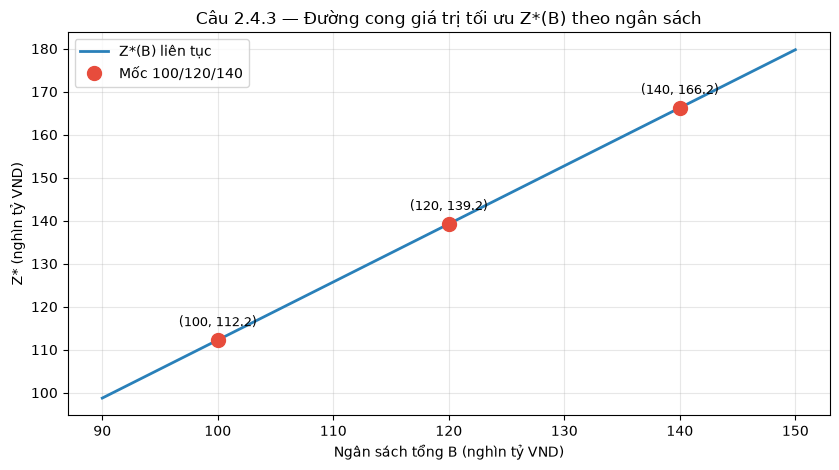

CÂU 2.4.4 — Thêm ràng buộc x3 >= 30 (ưu tiên kỹ sư AI)
Trạng thái: KHẢ THI — Optimization terminated successfully. (HiGHS Status 7: Optimal)
>>> Z* mới = 108.2500
>>> Phân bổ mới:
           Hạng mục  x* (cũ, x3>=20)  x* (mới, x3>=30)
     x1: Hạ tầng số             25.0              25.0
  x2: R&D công nghệ             15.0              15.0
    x3: Nhân lực số             20.0              30.0
x4: Doanh nghiệp AI             40.0              30.0

NHẬN XÉT:
  • Bài toán VẪN KHẢ THI: tổng các sàn = 25+15+30+10 = 80 <= 100, và
    ràng buộc cân đối cơ cấu vẫn thỏa -> tồn tại nghiệm hợp lệ.
  • Z* giảm từ 112.25 -> 108.25 (giảm 4.00 nghìn tỷ, tức 3.56%).
  • Lý do: buộc rót thêm 10 vào x3 (lợi ích biên 0.95) đồng nghĩa
    rút bớt khỏi x4 (lợi ích biên 1.35) — phần chênh 0.40/đơn vị × 10
    = 4.0 đúng bằng mức sụt giảm của Z*. Đây là "chi phí cơ hội"
    của mục tiêu chính sách ưu tiên nhân lực số.



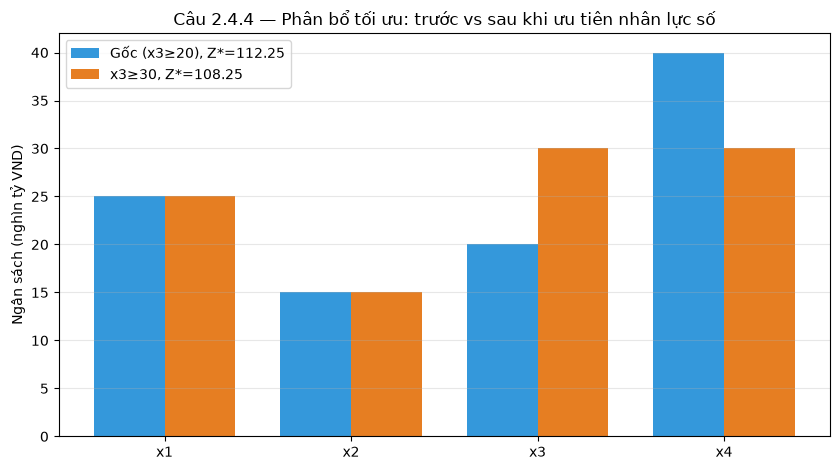


HOÀN TẤT BÀI 2 (Câu 2.4.1 -> 2.4.4)


In [1]:
# =====================================================================
# BÀI 2 - PHÂN BỔ NGÂN SÁCH ĐẦU TƯ CHIẾN LƯỢC (LINEAR PROGRAMMING)
# Giải trọn vẹn Câu 2.4.1 -> 2.4.4 trong MỘT cell (Google Colab)
# Biến: x1, x2, x3, x4 = ngân sách (nghìn tỷ VND) cho 4 hạng mục
#   x1: hạ tầng số | x2: R&D/công nghệ lõi | x3: nhân lực số | x4: doanh nghiệp AI
# Mục tiêu: tối đa hóa Z = 0.85x1 + 1.20x2 + 0.95x3 + 1.35x4  (lợi ích kỳ vọng)
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog

# Cài pulp nếu Colab chưa có
try:
    import pulp
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pulp"])
    import pulp

# ---- Tham số bài toán -------------------------------------------------
profit = np.array([0.85, 1.20, 0.95, 1.35])   # hệ số mục tiêu (lợi ích / 1 đơn vị vốn)
names  = ['x1: Hạ tầng số', 'x2: R&D công nghệ', 'x3: Nhân lực số', 'x4: Doanh nghiệp AI']
floors = np.array([25, 15, 20, 10])           # mức sàn tối thiểu mỗi hạng mục
BUDGET = 100                                  # ngân sách tổng (nghìn tỷ VND)

# Ràng buộc bất đẳng thức A_ub x <= b_ub (dạng linprog) -----------------
#  (1) tổng ngân sách:           x1+x2+x3+x4 <= B
#  (2)-(5) sàn tối thiểu:        -xi <= -floor_i
#  (6) cân đối cơ cấu:           0.35(x1+x3) <= 0.65(x2+x4)
def build_constraints(B, x3_min=20):
    A_ub = [[1, 1, 1, 1],
            [-1, 0, 0, 0],
            [0, -1, 0, 0],
            [0, 0, -1, 0],
            [0, 0, 0, -1],
            [0.35, -0.65, 0.35, -0.65]]
    b_ub = [B, -25, -15, -x3_min, -10, 0]
    return A_ub, b_ub

con_labels = ['Ngân sách tổng', 'Sàn x1>=25', 'Sàn x2>=15',
              'Sàn x3 (min)', 'Sàn x4>=10', 'Cân đối cơ cấu']

# =====================================================================
# CÂU 2.4.1 — GIẢI BẰNG scipy.optimize.linprog
# =====================================================================
print("="*70)
print("CÂU 2.4.1 — Giải bằng scipy.optimize.linprog (HiGHS)")
print("="*70)

c = (-profit).tolist()                         # max Z  <=>  min (-Z)
A_ub, b_ub = build_constraints(BUDGET)
res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=[(0, None)]*4, method='highs')

Z_opt = -res.fun
x_opt = res.x
print(f"Trạng thái: {res.message}")
print(f"\n>>> Giá trị tối ưu  Z* = {Z_opt:.4f}  (nghìn tỷ VND lợi ích)")
print(">>> Phân bổ tối ưu:")
tab_241 = pd.DataFrame({
    'Hạng mục': names,
    'Phân bổ x* (ngh.tỷ)': x_opt.round(3),
    'Tỷ trọng (%)': (x_opt / x_opt.sum() * 100).round(1),
    'Hệ số lợi ích': profit
})
print(tab_241.to_string(index=False))
print(f"\nTổng vốn sử dụng = {x_opt.sum():.2f} / {BUDGET}  "
      f"(còn dư {BUDGET - x_opt.sum():.2f})")

# =====================================================================
# CÂU 2.4.2 — GIẢI LẠI BẰNG PULP + GIÁ ĐỐI NGẪU (SHADOW PRICE)
# =====================================================================
print("\n" + "="*70)
print("CÂU 2.4.2 — Giải bằng PuLP và xuất giá đối ngẫu (dual values)")
print("="*70)

prob = pulp.LpProblem("Budget_Allocation", pulp.LpMaximize)
x = [pulp.LpVariable(f"x{i+1}", lowBound=0) for i in range(4)]

# Hàm mục tiêu
prob += pulp.lpSum(profit[i] * x[i] for i in range(4)), "Total_Benefit"

# Ràng buộc (đặt tên để lấy dual) - viết theo dạng "tự nhiên"
c_budget  = pulp.lpSum(x) <= BUDGET;                         prob += (c_budget,  "NganSachTong")
c_x1      = x[0] >= 25;                                      prob += (c_x1,      "San_x1")
c_x2      = x[1] >= 15;                                      prob += (c_x2,      "San_x2")
c_x3      = x[2] >= 20;                                      prob += (c_x3,      "San_x3")
c_x4      = x[3] >= 10;                                      prob += (c_x4,      "San_x4")
c_balance = 0.35*(x[0]+x[2]) <= 0.65*(x[1]+x[3]);            prob += (c_balance, "CanDoiCoCau")

prob.solve(pulp.PULP_CBC_CMD(msg=0))

print(f"Trạng thái PuLP: {pulp.LpStatus[prob.status]}")
print(f">>> Z* (PuLP) = {pulp.value(prob.objective):.4f}")
print(">>> Phân bổ:", {f"x{i+1}": round(x[i].value(), 3) for i in range(4)})

print("\nGiá đối ngẫu (shadow price) từng ràng buộc:")
dual_rows = []
for cname, cobj in prob.constraints.items():
    dual_rows.append({'Ràng buộc': cname,
                      'Shadow price': round(cobj.pi, 4),
                      'Slack': round(cobj.slack, 4)})
dual_df = pd.DataFrame(dual_rows)
print(dual_df.to_string(index=False))

# Lấy riêng shadow price của ngân sách tổng
sp_budget = prob.constraints['NganSachTong'].pi
print(f"""
GIẢI THÍCH CHÍNH SÁCH — shadow price ngân sách tổng = {sp_budget:.4f}
  • Ý nghĩa: nếu tăng ngân sách tổng thêm 1 nghìn tỷ VND (trong khoảng
    còn hiệu lực của cơ sở tối ưu), tổng lợi ích Z* sẽ tăng thêm
    khoảng {sp_budget:.2f} nghìn tỷ VND.
  • Vì shadow price = {sp_budget:.2f} > 0 và bằng đúng hệ số lợi ích cao
    nhất (x4 = 1.35), mỗi đồng tăng thêm sẽ được rót vào hạng mục
    sinh lời nhất (doanh nghiệp AI). Ràng buộc ngân sách đang "chặt"
    (binding) — ngân sách là nguồn lực khan hiếm quyết định Z*.
  • Hàm ý chính sách: nới ngân sách có hiệu suất biên dương rõ rệt;
    ưu tiên cấp thêm vốn cho tới khi shadow price giảm (đổi cơ sở).
""")

# =====================================================================
# CÂU 2.4.3 — PHÂN TÍCH ĐỘ NHẠY THEO NGÂN SÁCH: Z*(B)
# =====================================================================
print("="*70)
print("CÂU 2.4.3 — Độ nhạy: tăng ngân sách 100 -> 120 -> 140, vẽ Z*(B)")
print("="*70)

B_list = [100, 120, 140]
Z_list, X_list = [], []
for B in B_list:
    A_b, b_b = build_constraints(B)
    r = linprog(c, A_ub=A_b, b_ub=b_b, bounds=[(0, None)]*4, method='highs')
    Z_list.append(-r.fun); X_list.append(r.x)

tab_243 = pd.DataFrame({
    'Ngân sách B': B_list,
    'Z* tối ưu': [round(z, 3) for z in Z_list],
    'x1': [round(xx[0], 1) for xx in X_list],
    'x2': [round(xx[1], 1) for xx in X_list],
    'x3': [round(xx[2], 1) for xx in X_list],
    'x4': [round(xx[3], 1) for xx in X_list],
})
print(tab_243.to_string(index=False))

# Độ dốc (lợi ích biên của ngân sách) giữa các mốc
for i in range(1, len(B_list)):
    slope = (Z_list[i]-Z_list[i-1]) / (B_list[i]-B_list[i-1])
    print(f"  ΔZ*/ΔB trên [{B_list[i-1]},{B_list[i]}] = {slope:.3f}  (≈ shadow price)")

# Vẽ đường cong Z*(B) với lưới mịn
B_grid = np.linspace(90, 150, 61)
Z_grid = []
for B in B_grid:
    A_b, b_b = build_constraints(B)
    r = linprog(c, A_ub=A_b, b_ub=b_b, bounds=[(0, None)]*4, method='highs')
    Z_grid.append(-r.fun)

plt.figure(figsize=(8.5, 4.8))
plt.plot(B_grid, Z_grid, '-', lw=2, color='#2980b9', label='Z*(B) liên tục')
plt.plot(B_list, Z_list, 'o', ms=10, color='#e74c3c', label='Mốc 100/120/140')
for B, Z in zip(B_list, Z_list):
    plt.annotate(f'({B}, {Z:.1f})', (B, Z), textcoords="offset points",
                 xytext=(0, 10), ha='center', fontsize=9)
plt.title('Câu 2.4.3 — Đường cong giá trị tối ưu Z*(B) theo ngân sách', fontsize=12)
plt.xlabel('Ngân sách tổng B (nghìn tỷ VND)')
plt.ylabel('Z* (nghìn tỷ VND)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# =====================================================================
# CÂU 2.4.4 — ƯU TIÊN NHÂN LỰC SỐ: RÀNG BUỘC x3 >= 30
# =====================================================================
print("="*70)
print("CÂU 2.4.4 — Thêm ràng buộc x3 >= 30 (ưu tiên kỹ sư AI)")
print("="*70)

A_new, b_new = build_constraints(BUDGET, x3_min=30)   # thay sàn x3: 20 -> 30
res2 = linprog(c, A_ub=A_new, b_ub=b_new, bounds=[(0, None)]*4, method='highs')

if res2.status == 0:
    Z_new = -res2.fun
    print(f"Trạng thái: KHẢ THI — {res2.message}")
    print(f">>> Z* mới = {Z_new:.4f}")
    print(">>> Phân bổ mới:")
    tab_244 = pd.DataFrame({
        'Hạng mục': names,
        'x* (cũ, x3>=20)': x_opt.round(2),
        'x* (mới, x3>=30)': res2.x.round(2),
    })
    print(tab_244.to_string(index=False))
    dZ = Z_new - Z_opt
    print(f"""
NHẬN XÉT:
  • Bài toán VẪN KHẢ THI: tổng các sàn = 25+15+30+10 = 80 <= 100, và
    ràng buộc cân đối cơ cấu vẫn thỏa -> tồn tại nghiệm hợp lệ.
  • Z* giảm từ {Z_opt:.2f} -> {Z_new:.2f} (giảm {abs(dZ):.2f} nghìn tỷ, tức {abs(dZ)/Z_opt*100:.2f}%).
  • Lý do: buộc rót thêm 10 vào x3 (lợi ích biên 0.95) đồng nghĩa
    rút bớt khỏi x4 (lợi ích biên 1.35) — phần chênh 0.40/đơn vị × 10
    = 4.0 đúng bằng mức sụt giảm của Z*. Đây là "chi phí cơ hội"
    của mục tiêu chính sách ưu tiên nhân lực số.
""")
else:
    print(f"Trạng thái: KHÔNG KHẢ THI — {res2.message}")

# Biểu đồ so sánh phân bổ cũ vs mới
labels = ['x1', 'x2', 'x3', 'x4']
xpos = np.arange(4); w = 0.38
plt.figure(figsize=(8.5, 4.8))
plt.bar(xpos - w/2, x_opt, w, label=f'Gốc (x3≥20), Z*={Z_opt:.2f}', color='#3498db')
if res2.status == 0:
    plt.bar(xpos + w/2, res2.x, w, label=f'x3≥30, Z*={-res2.fun:.2f}', color='#e67e22')
plt.xticks(xpos, labels)
plt.title('Câu 2.4.4 — Phân bổ tối ưu: trước vs sau khi ưu tiên nhân lực số', fontsize=12)
plt.ylabel('Ngân sách (nghìn tỷ VND)')
plt.legend(); plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

print("\n" + "="*70)
print("HOÀN TẤT BÀI 2 (Câu 2.4.1 -> 2.4.4)")
print("="*70)